In [2]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("../../../data/Train/train.csv",sep = ";")
df.head(5)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11
1,abfdd1,2025-01-01 12:53:57.851,2025-01-01 12:54:15.692,2025-01-01 12:55:08.113,70.262,Heavy (larger than 136000 kg),-3.572788,40.491846,-3.573818,40.491858,Z3,False,18R/36L,2025-01-01,12
2,4cacdf,2025-01-01 10:20:25.104,2025-01-01 10:20:38.071,2025-01-01 10:21:24.027,58.923,Medium 2 (between 34000 kg to 136000 kg),-3.561172,40.501179,-3.560085,40.501343,Y3,False,18L/36R,2025-01-01,10
3,34754c,2025-01-01 05:37:49.944,2025-01-01 05:38:03.062,2025-01-01 05:38:52.151,62.207,Medium 2 (between 34000 kg to 136000 kg),-3.576462,40.492481,-3.575488,40.492766,Z4,False,18R/36L,2025-01-01,5
4,34754c,2025-01-01 12:45:58.757,2025-01-01 12:46:16.737,2025-01-01 12:48:41.019,162.262,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492475,-3.575519,40.492777,Z4,False,18R/36L,2025-01-01,12


In [3]:
## Nos quedamos solo con los que han parado, como en el caso de los escenarios
df = df[df["parado"] == True]
## Eliminamos los NA
df = df.dropna().reset_index(drop=True)
df.head(5)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,149.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12
1,34644c,2025-01-01 10:39:59.985,2025-01-01 10:41:54.188,2025-01-01 10:45:04.579,304.594,Medium 2 (between 34000 kg to 136000 kg),-3.576385,40.491760,-3.575348,40.492081,Z2,True,18R/36L,2025-01-01,10
2,34644c,2025-01-01 18:15:03.927,2025-01-01 18:16:07.879,2025-01-01 18:18:50.910,226.983,Medium 2 (between 34000 kg to 136000 kg),-3.576580,40.492568,-3.575535,40.492836,Z4,True,18R/36L,2025-01-01,18
3,345698,2025-01-01 08:06:24.591,2025-01-01 08:07:28.767,2025-01-01 08:08:32.884,128.293,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.501262,-3.560054,40.501308,Y3,True,18L/36R,2025-01-01,8
4,345698,2025-01-01 15:24:07.211,2025-01-01 15:25:59.416,2025-01-01 15:27:13.716,186.505,Medium 2 (between 34000 kg to 136000 kg),-3.561193,40.499411,-3.560089,40.499588,Y1,True,18L/36R,2025-01-01,15


In [4]:
## Cambiar el formato de los tiempos
timestap_columns = ["llegada_punto","salida_punto","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
llegada_punto     datetime64[ns]
salida_punto      datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
llegada_lon              float64
llegada_lat              float64
salida_lon               float64
salida_lat               float64
holding_point             object
parado                      bool
runway                    object
fecha_despegue    datetime64[ns]
hora_despegue              int64
dtype: object

In [5]:
## Aplicar OneHotEncoding a las columnas categóricas salvo el ICAO y el runway
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO","runway"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = ["runway"])
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [6]:
df_encoded.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LC,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,149.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,34644c,2025-01-01 10:39:59.985,2025-01-01 10:41:54.188,2025-01-01 10:45:04.579,304.594,Medium 2 (between 34000 kg to 136000 kg),-3.576385,40.491760,-3.575348,40.492081,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,34644c,2025-01-01 18:15:03.927,2025-01-01 18:16:07.879,2025-01-01 18:18:50.910,226.983,Medium 2 (between 34000 kg to 136000 kg),-3.576580,40.492568,-3.575535,40.492836,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,345698,2025-01-01 08:06:24.591,2025-01-01 08:07:28.767,2025-01-01 08:08:32.884,128.293,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.501262,-3.560054,40.501308,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,345698,2025-01-01 15:24:07.211,2025-01-01 15:25:59.416,2025-01-01 15:27:13.716,186.505,Medium 2 (between 34000 kg to 136000 kg),-3.561193,40.499411,-3.560089,40.499588,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
## Observamos que tenemos outliers en el tiempo de espera
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()

df_encoded_sorted["tiempo_espera"].describe()

count    13909.000000
mean       283.022624
std       1213.518916
min         25.102000
25%        162.245000
50%        207.838000
75%        282.676000
max      62349.942000
Name: tiempo_espera, dtype: float64

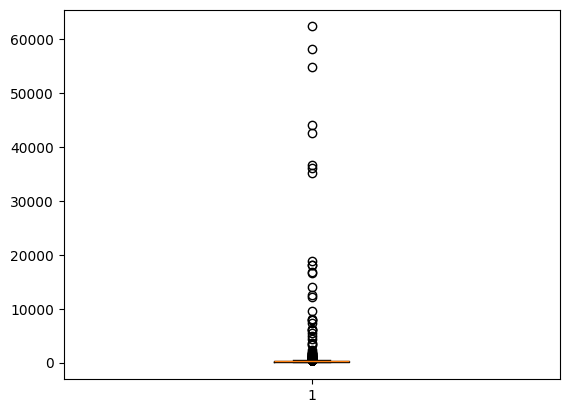

In [8]:
import matplotlib.pyplot as plt

plt.boxplot(df_encoded_sorted["tiempo_espera"])
plt.show()

In [9]:
## En esta aproximación eliminamos los outliers que están por encima de 1.5 veces el IQR
Q1 = df_encoded_sorted['tiempo_espera'].quantile(0.25)  # Primer cuartil
Q3 = df_encoded_sorted['tiempo_espera'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1  # Rango intercuartílico

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores dentro de los límites
df_sin_outliers = df_encoded_sorted[(df_encoded_sorted['tiempo_espera'] >= limite_inferior) & (df_encoded_sorted['tiempo_espera'] <= limite_superior)]

print("DataFrame sin outliers:")
print(limite_inferior,limite_superior)
df_sin_outliers.head()

DataFrame sin outliers:
-18.40149999999997 463.3225


,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LC,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,Heavy (larger than 136000 kg),-3.572540,40.490582,-3.573532,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,281.260,Heavy (larger than 136000 kg),-3.572617,40.491835,-3.573834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5078,344455,2025-01-31 22:08:24.111,2025-01-31 22:09:25.906,2025-01-31 22:10:51.249,147.138,Medium 2 (between 34000 kg to 136000 kg),-3.576553,40.492527,-3.575500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5085,06a2e9,2025-01-31 21:19:30.275,2025-01-31 21:22:27.896,2025-01-31 21:23:29.572,239.297,Heavy (larger than 136000 kg),-3.561240,40.499423,-3.560089,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5031,347588,2025-01-31 20:58:19.231,2025-01-31 20:59:18.150,2025-01-31 21:01:31.838,192.607,Medium 2 (between 34000 kg to 136000 kg),-3.576599,40.492481,-3.575485,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<Axes: >

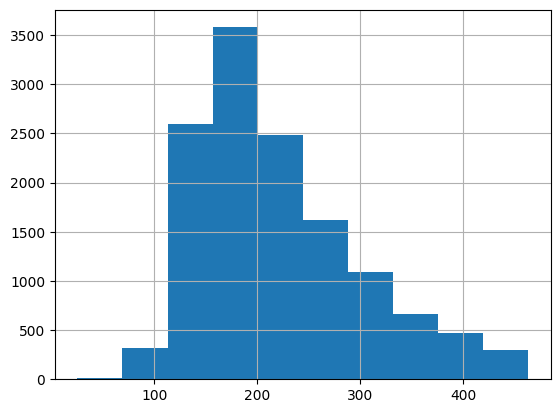

In [10]:
## Hemos conseguido mejorar la distribución de los tiempos de espera
df_sin_outliers["tiempo_espera"].hist()

In [11]:
df_sin_outliers = df_sin_outliers.sort_values(by = "despegue").reset_index(drop =True)
df_sin_outliers.head(5)

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LC,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5252,4cac23,2024-11-07 05:02:02.902,2024-11-07 05:06:03.386,2024-11-07 05:07:29.534,326.632,Medium 2 (between 34000 kg to 136000 kg),-3.576614,40.492493,-3.575500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,5388,484fde,2024-11-07 05:14:26.585,2024-11-07 05:15:36.338,2024-11-07 05:18:33.536,246.951,Medium 2 (between 34000 kg to 136000 kg),-3.576456,40.491753,-3.575378,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,5333,896441,2024-11-07 05:35:39.252,2024-11-07 05:36:26.584,2024-11-07 05:37:34.211,114.959,Heavy (larger than 136000 kg),-3.576614,40.492481,-3.575519,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5160,344498,2024-11-07 05:39:04.831,2024-11-07 05:41:53.272,2024-11-07 05:43:01.991,237.160,Medium 2 (between 34000 kg to 136000 kg),-3.576424,40.492486,-3.575488,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def resample_flight_data(df, interval_seconds=30):
    """
    Resample flight data to create rows at fixed intervals between arrival and departure times.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing flight data with columns 'ICAO', 'llegada_punto', 'salida_punto'
    interval_seconds : int
        Interval in seconds for resampling
        
    Returns:
    --------
    pandas.DataFrame
        Resampled DataFrame with additional rows and tiempo_esperando column
    """
    # Ensure datetime format
    df['llegada_punto'] = pd.to_datetime(df['llegada_punto'])
    df['salida_punto'] = pd.to_datetime(df['salida_punto'])
    
    # Create a list to store the resampled rows
    resampled_rows = []
    
    # For each flight in the original DataFrame
    for _, flight in df.iterrows():
        # Get arrival and departure times
        arrival_time = flight['llegada_punto']
        departure_time = flight['salida_punto']
        tiempo_espera = flight["tiempo_espera"]
        
        # Calculate how many intervals fit between arrival and departure
        time_diff = (departure_time - arrival_time).total_seconds()
        num_intervals = int(time_diff / interval_seconds) + 1
        
        # Create a row for each interval
        for i in range(num_intervals):
            # Calculate the current timestamp
            current_time = arrival_time + timedelta(seconds=i * interval_seconds)
            
            # If we've exceeded the departure time, break
            if current_time > departure_time:
                break
                
            # Create a new row with the original data
            new_row = flight.copy()
            
            # Calculate tiempo_esperando in seconds
            tiempo_esperando = (current_time - arrival_time).total_seconds()
            
            # Add the new column
            new_row['tiempo_esperado'] = tiempo_esperando
            #new_row['timestamp'] = current_time
            new_row["tiempo_espera"] = tiempo_espera -  tiempo_esperando
            new_row["llegada_punto"]+=  (current_time - arrival_time)
            
            # Add the row to our collection
            resampled_rows.append(new_row)
    
    # Create a new DataFrame from the resampled rows
    resampled_df = pd.DataFrame(resampled_rows)
    
    return resampled_df



In [13]:
## Usamos nuestro funcion para resamplear los datos,de esta forma tenemos una nueva columna con el tiempo que lleva esperando el avion en el punto de espera
df_sin_outliers = resample_flight_data(df_sin_outliers)


In [14]:
df_sin_outliers = df_sin_outliers.reset_index(drop = True)
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperado
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5185,347518,2024-11-07 00:22:41.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,308.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0
2,5185,347518,2024-11-07 00:23:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,278.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0
3,5185,347518,2024-11-07 00:23:41.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,248.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
4,5185,347518,2024-11-07 00:24:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,218.237,Heavy (larger than 136000 kg),-3.561225,40.499423,-3.560089,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60161,5103,347386,2025-01-31 23:07:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,161.260,Heavy (larger than 136000 kg),-3.572617,40.491835,-3.573834,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,120.0
60162,5103,347386,2025-01-31 23:08:28.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,131.260,Heavy (larger than 136000 kg),-3.572617,40.491835,-3.573834,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,150.0
60163,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,Heavy (larger than 136000 kg),-3.572540,40.490582,-3.573532,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
60164,5003,347519,2025-01-31 23:25:41.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,169.739,Heavy (larger than 136000 kg),-3.572540,40.490582,-3.573532,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,30.0


In [15]:
## Ahora vamos a obtener los holding points que estan ocupados en el momento de la llegada del avion
lista = []
for i, (index, row) in enumerate(df_sin_outliers.iterrows()):
    if (i -1)>=0:
        llegada_punto_referencia,salida_punto_referencia,despegue,holding_referencia,icao_referencia = row["llegada_punto"],row["salida_punto"],row["despegue"],row["holding_point"],row["ICAO"]
        filtered_df = df_sin_outliers[(df_sin_outliers["llegada_punto"] < llegada_punto_referencia) & (df_sin_outliers["salida_punto"] > llegada_punto_referencia)]
        filtered_df = filtered_df[filtered_df["ICAO"] != icao_referencia]
        lista.append(filtered_df[["index", "holding_point"]].values)

    

In [16]:
lista_filtrada = [
    [(idx, val) for idx, val in arr if val is not None]
    for arr in lista[1:] if any(val is not None for _, val in arr)
]


In [17]:
## Obtenemos para cada indice de avion, que otros holding points estan ocupados en el momento de la llegada del avion
lista_filtrada[:5] 

[[(5205, 'Z4'), (5205, 'Z4'), (5205, 'Z4'), (5205, 'Z4'), (5205, 'Z4')],
 [(5358, 'Z4')],
 [(5358, 'Z4'), (5358, 'Z4')],
 [(5189, 'Y1'), (5189, 'Y1')],
 [(5189, 'Y1'), (5189, 'Y1'), (5189, 'Y1')]]

In [19]:
from sklearn.cluster import DBSCAN
import numpy as np
## Solo nos interesan los holdin points que esten ocupados y cercanos al punto de espera del avion, por lo que vamos a crear cluster de holding points que esten cercanos
# Coordenadas extraídas del GeoJSON
coords = np.array([
    [-3.573093114831562, 40.490653160130186],  # Z1
    [-3.537524367869231, 40.472076292010001],  # KA6
    [-3.536653485337274, 40.466622566754253],  # KA8
    [-3.558959606954449, 40.494122669084419],  # K3
    [-3.559326044131887, 40.4945961819448],    # K2
    [-3.560411408421098, 40.495554592925956],  # K1
    [-3.560656492186808, 40.499431092287409],  # Y1
    [-3.560645785166937, 40.500298406173002],  # Y2
    [-3.560660061193443, 40.501183565039504],  # Y3
    [-3.560800449906033, 40.533391949745102],  # Y7
    [-3.576129307304151, 40.495184843931881],  # Z6
    [-3.576034129003182, 40.492555539298088],  # Z4
    [-3.575903257941006, 40.491865496230126],  # Z2
    [-3.57319305240692, 40.491819096186241],   # Z3
    [-3.572566658955927, 40.479721203031424],  # LF
    [-3.57652786733783, 40.483565816902733],   # L1
    [-3.577181028787666, 40.484251101106899],  # LA
    [-3.577553413710587, 40.484873329796898],  # LB
    [-3.575750378154376, 40.486690643924192],  # LC
    [-3.575150753600524, 40.486522892072891],  # LD
    [-3.574915186586964, 40.485580625293494]   # LE
])

# Convertir a metros
lat_mean = np.deg2rad(40.5)  # Latitud media en radianes
meters_per_lat = 111000
meters_per_lon = 84000  # 111000 * cos(40.5°)
coords_meters = coords * np.array([meters_per_lon, meters_per_lat])

# Aplicar DBSCAN
db = DBSCAN(eps=250, min_samples=1, metric='euclidean').fit(coords_meters)
labels = db.labels_

# Lista de puntos
points = ['Z1', 'KA6', 'KA8', 'K3', 'K2', 'K1', 'Y1', 'Y2', 'Y3', 'Y7', 'Z6', 'Z4', 'Z2', 'Z3', 'LF', 'L1', 'LA', 'LB', 'LC', 'LD', 'LE']

# Crear diccionario
mapping = {points[i]: f'Cluster_{labels[i]}' for i in range(len(points))}
print(mapping)

{'Z1': 'Cluster_0', 'KA6': 'Cluster_1', 'KA8': 'Cluster_2', 'K3': 'Cluster_3', 'K2': 'Cluster_3', 'K1': 'Cluster_3', 'Y1': 'Cluster_4', 'Y2': 'Cluster_4', 'Y3': 'Cluster_4', 'Y7': 'Cluster_5', 'Z6': 'Cluster_6', 'Z4': 'Cluster_0', 'Z2': 'Cluster_0', 'Z3': 'Cluster_0', 'LF': 'Cluster_7', 'L1': 'Cluster_8', 'LA': 'Cluster_8', 'LB': 'Cluster_8', 'LC': 'Cluster_8', 'LD': 'Cluster_8', 'LE': 'Cluster_8'}


In [20]:
mapping

{'Z1': 'Cluster_0',
 'KA6': 'Cluster_1',
 'KA8': 'Cluster_2',
 'K3': 'Cluster_3',
 'K2': 'Cluster_3',
 'K1': 'Cluster_3',
 'Y1': 'Cluster_4',
 'Y2': 'Cluster_4',
 'Y3': 'Cluster_4',
 'Y7': 'Cluster_5',
 'Z6': 'Cluster_6',
 'Z4': 'Cluster_0',
 'Z2': 'Cluster_0',
 'Z3': 'Cluster_0',
 'LF': 'Cluster_7',
 'L1': 'Cluster_8',
 'LA': 'Cluster_8',
 'LB': 'Cluster_8',
 'LC': 'Cluster_8',
 'LD': 'Cluster_8',
 'LE': 'Cluster_8'}

In [21]:
# Vamoa a crear una nueva columna que sea pistas ocupadas con la información del numero de pistas ocupadas adyacentes al punto de espera donde esta el avion
# Procesar lista_filtrada para contar holding points únicos por índice
from collections import defaultdict
holding_points_por_indice = defaultdict(set)
for sublista in lista_filtrada:
    indice = sublista[0][0]  # El índice es el mismo en toda la sublista
    for _, hp in sublista:
        holding_points_por_indice[indice].add(hp)



nuevo_dict = defaultdict(set)
for indice, holdings in holding_points_por_indice.items():
    nuevo_dict[indice] = {mapping[holding] for holding in holdings}

# Convertir a dict normal si lo prefieres
nuevo_dict = dict(nuevo_dict)

# Crear un diccionario con la cantidad de holding points únicos por índice
cantidad_hp_por_indice = {indice: len(hps) for indice, hps in nuevo_dict.items()}

# Añadir la columna 'pistas_ocupadas' al DataFrame
# Suponiendo que df_sin_outliers ya está definido (asegúrate de tenerlo cargado)
import pandas as pd
# Ejemplo: si no lo tienes cargado, descomenta y ajusta esto con tus datos reales
# df_sin_outliers = pd.read_csv('tu_archivo.csv')  

df_sin_outliers['pistas_ocupadas'] = df_sin_outliers['index'].map(cantidad_hp_por_indice).fillna(0).astype(int)

# Mostrar las primeras filas para verificar
print(df_sin_outliers[['index', 'ICAO', 'llegada_punto', 'salida_punto', 'pistas_ocupadas']].head())

   index    ICAO           llegada_punto            salida_punto  \
0   5185  347518 2024-11-07 00:22:11.293 2024-11-07 00:26:28.694   
1   5185  347518 2024-11-07 00:22:41.293 2024-11-07 00:26:28.694   
2   5185  347518 2024-11-07 00:23:11.293 2024-11-07 00:26:28.694   
3   5185  347518 2024-11-07 00:23:41.293 2024-11-07 00:26:28.694   
4   5185  347518 2024-11-07 00:24:11.293 2024-11-07 00:26:28.694   

   pistas_ocupadas  
0                0  
1                0  
2                0  
3                0  
4                0  


In [22]:
df_sin_outliers["pistas_ocupadas"].value_counts()

pistas_ocupadas
1    30152
0    25752
2     4262
Name: count, dtype: int64

In [23]:
df_sin_outliers.dtypes

index                                                              int64
ICAO                                                              object
llegada_punto                                             datetime64[ns]
salida_punto                                              datetime64[ns]
despegue                                                  datetime64[ns]
tiempo_espera                                                    float64
aircraft_type                                                     object
llegada_lon                                                      float64
llegada_lat                                                      float64
salida_lon                                                       float64
salida_lat                                                       float64
holding_point                                                     object
parado                                                              bool
fecha_despegue                                     

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
X = df_sin_outliers.drop(columns=["tiempo_espera","index","ICAO","llegada_punto","salida_punto","despegue","fecha_despegue","holding_point","salida_lat","salida_lon","parado","hora_despegue","aircraft_type"])
y = df_sin_outliers["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test_indices = X_test.index

# Normalizar los datos de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construcción del modelo
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Capa de salida sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo con Early Stopping
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping]
)

# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")


Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 18270.9160 - mae: 106.4702 - val_loss: 4666.9307 - val_mae: 52.2945
Epoch 2/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6297.8066 - mae: 61.6515 - val_loss: 5043.3047 - val_mae: 53.2417
Epoch 3/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6186.2119 - mae: 60.8121 - val_loss: 4486.8428 - val_mae: 51.7880
Epoch 4/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6173.9697 - mae: 60.6433 - val_loss: 4450.9336 - val_mae: 51.5014
Epoch 5/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6123.7759 - mae: 60.5026 - val_loss: 4596.5518 - val_mae: 51.5758
Epoch 6/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6022.8398 - mae: 60.0581 - val_loss: 4772.7178 - val_mae: 51.8239
Epoch 7/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5975.1450 - mae: 59.7626 - val_loss: 4444.5054 - val_mae: 51.6206
Epoch 8/200
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5998.3862 - mae: 59.9728 - val_loss: 4423.3110 - val_mae: 51

In [174]:
model.save("modelo_tiempo_espera_dense_sampled_con_pistas_ocupadas.keras")

In [26]:
y_pred = model.predict(X_test_scaled)

377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step


In [30]:
pd.concat([pd.DataFrame(df_sin_outliers.loc[X_test_indices].reset_index(drop = True)),pd.DataFrame(y_test.reset_index(drop = True)),pd.DataFrame(y_pred,columns = ["pred"])],axis =1).to_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/y_test_y_pred.csv")
pd.concat([pd.DataFrame(df_sin_outliers.loc[X_test_indices].reset_index(drop = True)),pd.DataFrame(y_test.reset_index(drop = True)),pd.DataFrame(y_pred,columns = ["pred"])],axis =1)

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,...,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperado,pistas_ocupadas,tiempo_espera,pred
0,5760,e80471,2024-11-09 21:44:17.231,2024-11-09 21:47:22.818,2024-11-09 21:48:33.041,255.810,Heavy (larger than 136000 kg),-3.560959,40.495583,-3.559820,...,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0,255.810,181.376541
1,10569,34604e,2024-12-08 23:27:22.048,2024-12-08 23:28:09.231,2024-12-08 23:30:11.688,169.640,Heavy (larger than 136000 kg),-3.572523,40.490578,-3.573563,...,0.0,1.0,0.0,0.0,0.0,0.0,120.0,0,169.640,164.231308
2,1032,344217,2025-01-06 14:16:14.485,2025-01-06 14:17:45.935,2025-01-06 14:20:12.633,238.148,Medium 2 (between 34000 kg to 136000 kg),-3.576599,40.492596,-3.575592,...,0.0,0.0,0.0,0.0,1.0,0.0,30.0,0,238.148,174.447800
3,9960,34750b,2024-12-05 14:20:46.382,2024-12-05 14:22:20.509,2024-12-05 14:23:38.491,172.109,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492556,-3.575546,...,0.0,0.0,0.0,0.0,1.0,0.0,30.0,1,172.109,228.862228
4,7034,346499,2024-11-15 13:58:47.079,2024-11-15 14:02:38.908,2024-11-15 14:04:04.322,317.243,Medium 2 (between 34000 kg to 136000 kg),-3.560974,40.495594,-3.559820,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,317.243,235.580170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12029,3795,342090,2025-01-23 10:42:54.543,2025-01-23 10:43:15.577,2025-01-23 10:44:22.050,87.507,Medium 2 (between 34000 kg to 136000 kg),-3.576580,40.492463,-3.575424,...,0.0,0.0,0.0,0.0,1.0,0.0,60.0,0,87.507,157.021622
12030,10659,347588,2024-12-09 10:45:09.399,2024-12-09 10:46:41.787,2024-12-09 10:48:11.140,181.741,Medium 2 (between 34000 kg to 136000 kg),-3.576599,40.492481,-3.575504,...,0.0,0.0,0.0,0.0,1.0,0.0,30.0,1,181.741,228.998627
12031,6151,344417,2024-11-10 17:19:44.460,2024-11-10 17:20:05.765,2024-11-10 17:21:04.607,80.147,Medium 2 (between 34000 kg to 136000 kg),-3.561218,40.499439,-3.560101,...,0.0,0.0,0.0,0.0,0.0,0.0,120.0,0,80.147,122.474716
12032,9265,345685,2024-12-01 15:33:11.851,2024-12-01 15:33:28.896,2024-12-01 15:36:01.268,169.417,Medium 2 (between 34000 kg to 136000 kg),-3.576614,40.492493,-3.575504,...,0.0,0.0,0.0,0.0,1.0,0.0,60.0,1,169.417,208.222458


In [27]:
# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")

377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 4333.2588 - mae: 51.3124
Error absoluto medio en test: 51.15


In [28]:
# Crear gráfico interactivo con Plotly

results_df = pd.DataFrame({
    'holding_point': df_sin_outliers.loc[X_test_indices, 'holding_point'],
    'real': y_test.values,
    'predicho': y_pred.flatten(),
    'ICAO': df_sin_outliers.loc[X_test_indices, 'ICAO'],
    'llegada_punto': df_sin_outliers.loc[X_test_indices, 'llegada_punto'],
    'salida_punto': df_sin_outliers.loc[X_test_indices, 'salida_punto'],
    'despegue': df_sin_outliers.loc[X_test_indices, 'despegue'],
    'fecha_despegue': df_sin_outliers.loc[X_test_indices, 'fecha_despegue'],
    'pistas_ocupadas':df_sin_outliers.loc[X_test_indices, 'pistas_ocupadas'],
    'parado':df_sin_outliers.loc[X_test_indices,"parado"]
})
from plotly import graph_objects as go
import plotly.express as px
fig = go.Figure()

# Añadir trazas para cada holding_point
for point in results_df['holding_point'].unique():
    subset = results_df[results_df['holding_point'] == point]
    fig.add_trace(
        go.Scatter(
            x=subset['real'],
            y=subset['predicho'],
            mode='markers',
            name=point,
            text=[f"ICAO: {row['ICAO']}<br>"
                  f"Holding Point: {row['holding_point']}<br>"
                  f"Real: {row['real']:.2f}<br>"
                  f"Predicho: {row['predicho']:.2f}<br>"
                  f"Llegada: {row['llegada_punto']}<br>"
                  f"Salida: {row['salida_punto']}<br>"
                  f": {row['salida_punto']}<br>"
                  f"Despegue: {row['despegue']}<br>"
                  f"pistas_ocupadas: {row['pistas_ocupadas']}<br>"
                  f"Parado: {row['parado']}<br>"
                  f"Fecha: {row['fecha_despegue']}"
                  for _, row in subset.iterrows()],
            hoverinfo='text',
            visible=True
        )
    )

# Añadir línea de referencia y=x
min_val = min(results_df['real'].min(), results_df['predicho'].min())
max_val = max(results_df['real'].max(), results_df['predicho'].max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        line=dict(color='red', dash='dash'),
        name='y=x',
        visible=True
    )
)

# Crear botones para el filtro
buttons = [
    dict(
        label='Todos',
        method='update',
        args=[{'visible': [True] * len(results_df['holding_point'].unique()) + [True]},  # +1 para la línea y=x
              {'title': 'Predicciones vs Valores Reales (Todos los Holding Points)'}]
    )
]

for i, point in enumerate(results_df['holding_point'].unique()):
    visible = [False] * len(results_df['holding_point'].unique())
    visible[i] = True
    buttons.append(
        dict(
            label=point,
            method='update',
            args=[{'visible': visible + [True]},  # +[True] para mantener la línea y=x visible
                  {'title': f'Predicciones vs Valores Reales (Holding Point: {point})'}]
        )
    )

# Actualizar el layout con el dropdown
fig.update_layout(
    title='Predicciones vs Valores Reales por Holding Point',
    xaxis_title='Tiempo de espera real',
    yaxis_title='Tiempo de espera predicho',
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ],
    showlegend=True,
    hovermode='closest'
)

# Mostrar el gráfico
fig.show()

# Opcional: Gráfico de barras de error por holding_point
error_by_point = results_df.groupby('holding_point').apply(
    lambda x: np.mean(np.abs(x['real'] - x['predicho']))
)

fig_bar = px.bar(
    x=error_by_point.index,
    y=error_by_point.values,
    labels={'x': 'Holding Point', 'y': 'MAE'},
    title='Error Absoluto Medio por Holding Point'
)
fig_bar.update_layout(xaxis={'tickangle': 45})
fig_bar.show()

/var/folders/kf/v4wgzcdn2k5_yn3_h219svlm0000gn/T/ipykernel_13084/3878209168.py:105: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



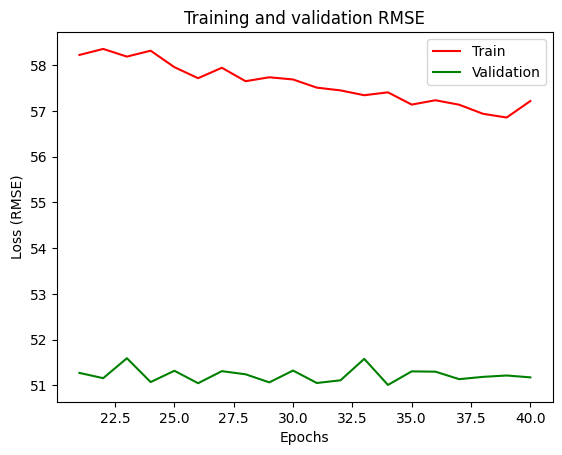

In [29]:
import matplotlib.pyplot as plt

loss = history.history['mae']
val_loss = history.history['val_mae']

epochs = range(1, len(loss) + 1)

plt.plot(epochs[20:], loss[20:], 'r', label='Train')
plt.plot(epochs[20:], val_loss[20:], 'g', label='Validation')

plt.title('Training and validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')
plt.legend()

plt.show()